In [1]:
import pandas as pd
import re
import numpy as np
from scipy import stats
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_hex

In [2]:
# Load data UTHealth
uthh = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/00uthhealth_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
uthh.rename(columns={uthh.columns[0]: "SampleID"}, inplace=True)

# Load data GSE
gse = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/02gse102556-08052025.csv")
# Rename the first column to SampleID
gse.rename(columns={gse.columns[0]: "SampleID"}, inplace=True)

# Load data VABB
vabb = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/01vabb_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
vabb.rename(columns={vabb.columns[0]: "SampleID"}, inplace=True)
# Replace the letter between numbers with an underscore
vabb["SampleID"] = vabb["SampleID"].str.replace(r"(?<=\d)[A-Z]+(?=\d)", "_", regex=True)

# Load data
dpclo = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo = dpclo.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank']]
# Add GSE from GEO cohort
# Load data
gse_kpann = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04gsecohort_kpnaa_clock_prediction-08052025.txt", sep = '\t')
gse_kpann = gse_kpann.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank']]
# Concatenate data
# Concatenate rows
kpann = pd.concat([dpclo, gse_kpann], axis=0, ignore_index=True)

# Merge with both filtered datasets
merged_df_com = pd.merge(kpann, uthh, on='SampleID')
merged_df2_com = pd.merge(kpann, vabb, on='SampleID')
merged_df3_com = pd.merge(kpann, gse, on='SampleID')
print(merged_df_com.shape)
print(merged_df2_com.shape)
print(merged_df3_com.shape)

(89, 212)
(546, 212)
(96, 219)


In [3]:
# --- 1. Subset relevant columns from both datasets ---
# Defining a function to extract the columns with brains and Age
def extract_age_and_brain(df, source_label):
    # Use 'AgeDeath' if available, otherwise fallback to 'Age'
    age_col = 'AgeDeath' if 'AgeDeath' in df.columns else 'Age'
    # Get columns that end with '_brain'
    brain_cols = [col for col in df.columns if col.endswith('_brain')]
    # Extract relevant columns
    subset = df[[age_col] + brain_cols].copy()
    # Rename age column to a common name
    subset.rename(columns={age_col: 'Age'}, inplace=True)
    # Drop rows with any NA values
    subset = subset.dropna()
    # Add source column
    subset['Source'] = source_label
    return subset

# Create subsets
uth_subset = extract_age_and_brain(merged_df_com, 'UTHealth')
vabb_subset = extract_age_and_brain(merged_df2_com, 'VABB')
gse_subset = extract_age_and_brain(merged_df3_com, 'GSE102556')
print(uth_subset.shape)
print(vabb_subset.shape)
print(gse_subset.shape)

# --- 2. Combine three datasets by row ---
# --- 1. Check column differences ---
cols_uth  = set(uth_subset.columns)
cols_vabb = set(vabb_subset.columns)
cols_gse  = set(gse_subset.columns)

print("Columns in UTH but not in VABB:", cols_uth - cols_vabb)
print("Columns in VABB but not in UTH:", cols_vabb - cols_uth)
print("Columns in UTH but not in GSE:", cols_uth - cols_gse)
print("Columns in GSE but not in UTH:", cols_gse - cols_uth)

# --- 2. Align all DataFrames to the same columns ---
# Union of all column names
all_cols = sorted(set(uth_subset.columns) | set(vabb_subset.columns) | set(gse_subset.columns))

# Reindex each DataFrame to have the same columns in the same order
uth_aligned  = uth_subset.reindex(columns=all_cols)
vabb_aligned = vabb_subset.reindex(columns=all_cols)
gse_aligned  = gse_subset.reindex(columns=all_cols)

# --- 3. Concatenate row-wise ---
combined_df = pd.concat([uth_aligned, vabb_aligned, gse_aligned], ignore_index=True)

(89, 11)
(546, 11)
(96, 11)
Columns in UTH but not in VABB: set()
Columns in VABB but not in UTH: set()
Columns in UTH but not in GSE: set()
Columns in GSE but not in UTH: set()


In [ ]:
# --- Save as CSV ---
#combined_df.to_csv("00cohorts_brainclocks-08252025.csv", index=False)
print(combined_df.head())

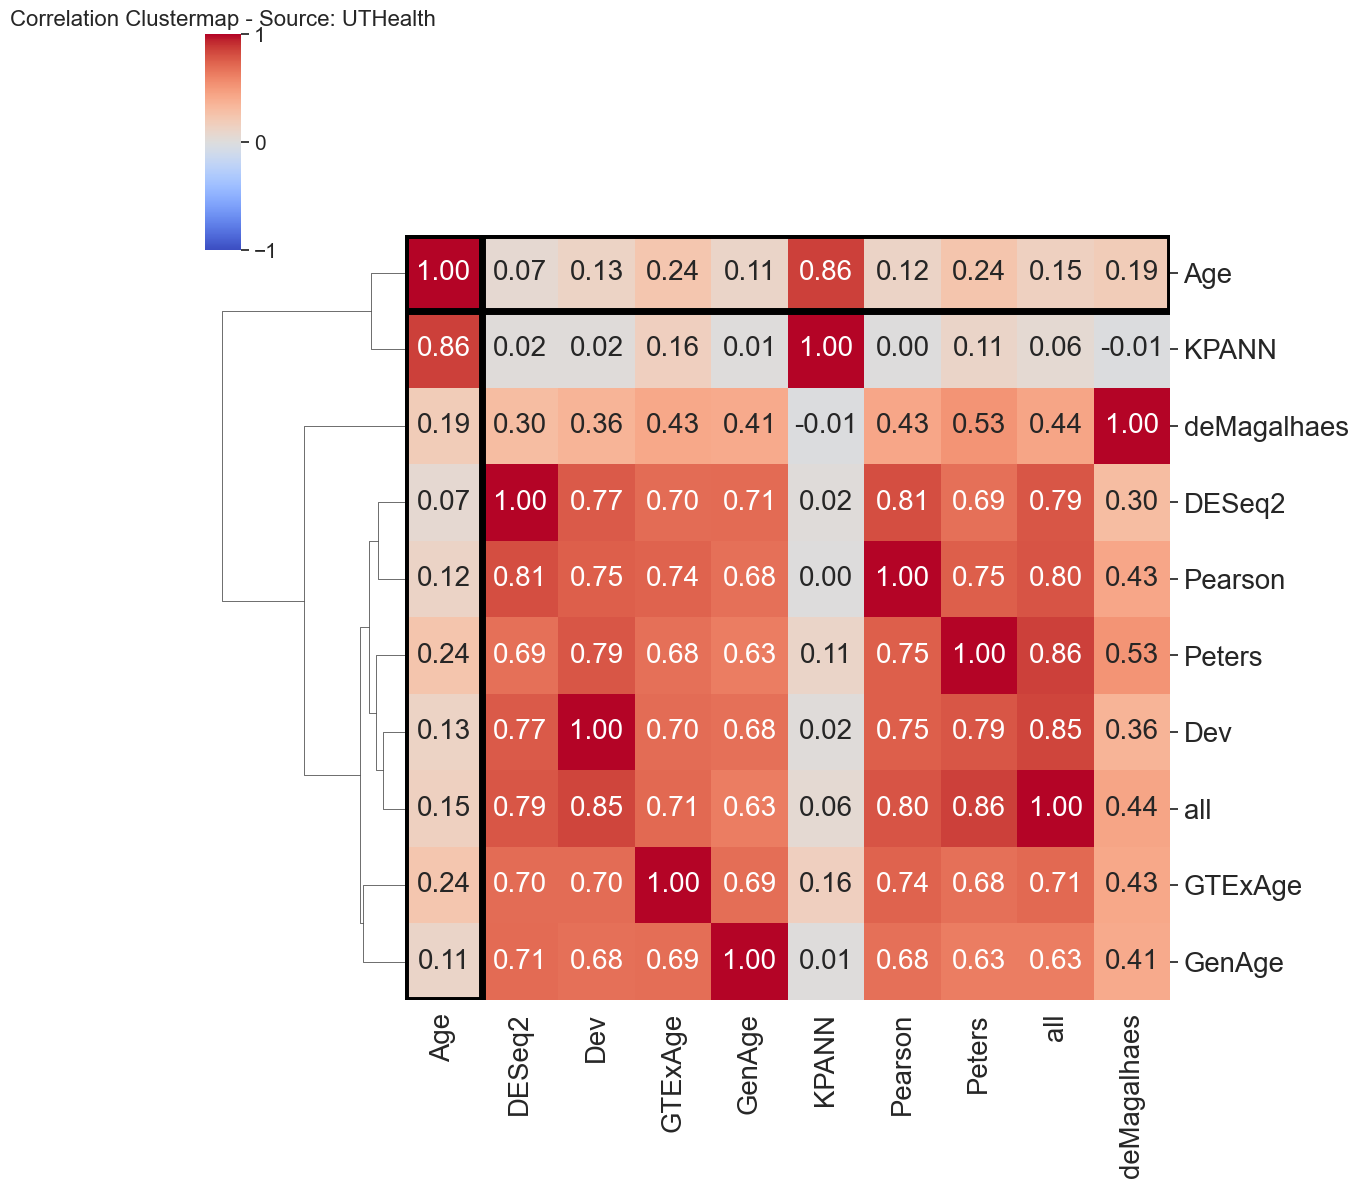

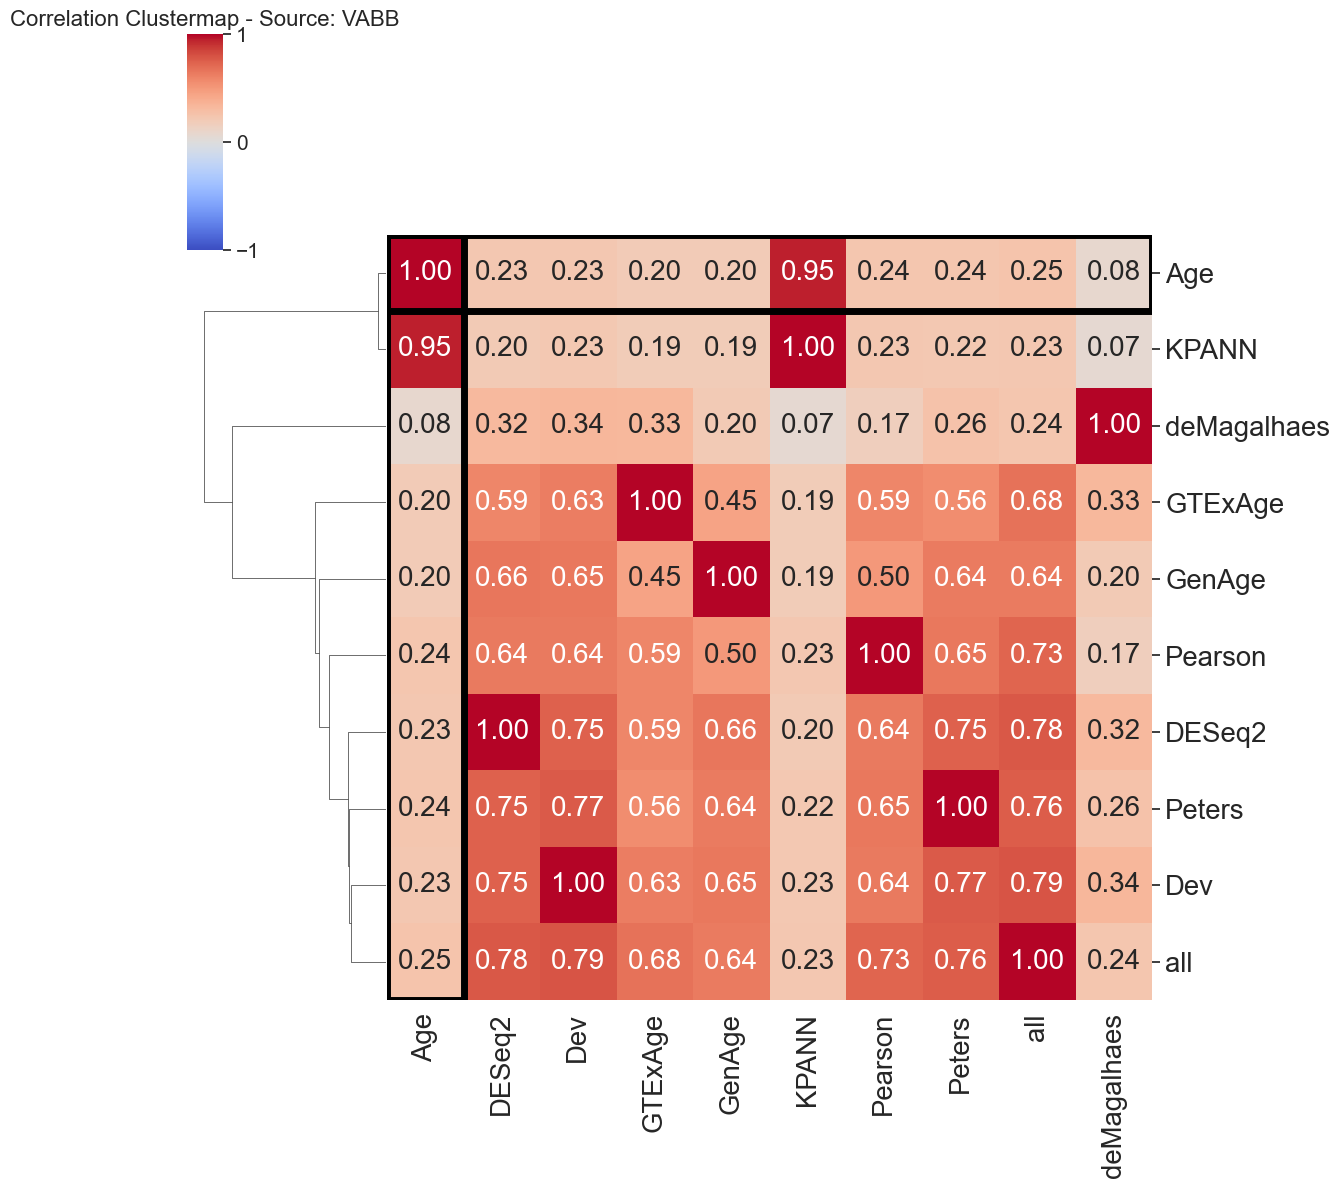

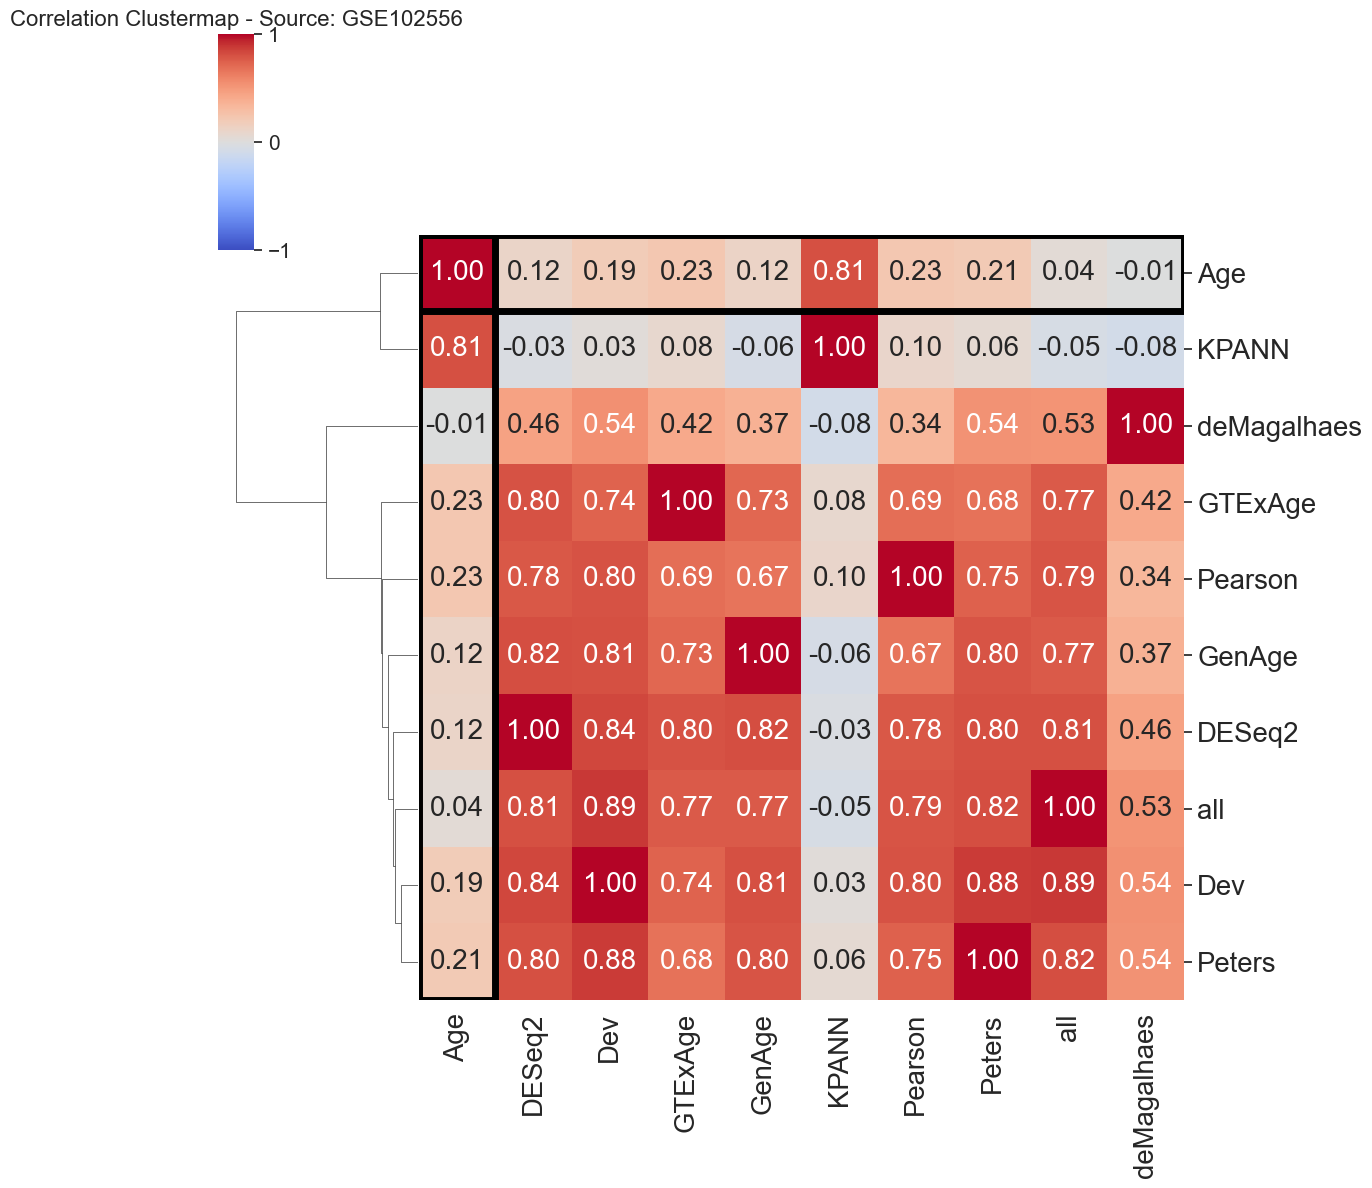

In [14]:
# Get unique sources
sources = combined_df["Source"].unique()

for src in sources:
    # Subset data for this source
    df_src = combined_df[combined_df["Source"] == src]
    
    # Compute correlation matrix (numeric only)
    corr_matrix = df_src.corr(numeric_only=True)
    
    # Clock columns (exclude Source)
    clock_cols = [col for col in corr_matrix.columns if col != "Source"]
    
    # Subset correlation matrix for clustering
    corr_clocks = corr_matrix.loc[clock_cols, clock_cols].copy()
    
    # Remove "_brain" from row and column labels
    corr_clocks.index = [x.replace("_brain", "") for x in corr_clocks.index]
    corr_clocks.columns = [x.replace("_brain", "") for x in corr_clocks.columns]
    
    # Plot clustermap
    sns.set(font_scale=1.8)
    cg = sns.clustermap(
        corr_clocks,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        figsize=(12, 12),
        col_cluster=False,
        annot_kws={"size": 20},
        cbar_pos=(0.02, 0.8, 0.03, 0.18)
    )
    
    # --- Highlight Age row and column if Age exists ---
    if "Age" in cg.data2d.index and "Age" in cg.data2d.columns:
        age_row_idx = list(cg.data2d.index).index("Age")
        age_col_idx = list(cg.data2d.columns).index("Age")
        
        # Draw rectangle around Age row
        cg.ax_heatmap.add_patch(plt.Rectangle(
            (0, age_row_idx), cg.data2d.shape[1], 1, fill=False, edgecolor='black', lw=5
        ))
        # Draw rectangle around Age column
        cg.ax_heatmap.add_patch(plt.Rectangle(
            (age_col_idx, 0), 1, cg.data2d.shape[0], fill=False, edgecolor='black', lw=5
        ))
    
    # Axis labels
    plt.xticks(fontsize=15, rotation=45)
    plt.yticks(fontsize=15)
    plt.title(f"Correlation Clustermap - Source: {src}", fontsize=16)
    
    # Save figure
    filename = f"03Fig2_Matrix_{src}_Brain.pdf"
    plt.savefig(filename, format="pdf", dpi=600, bbox_inches="tight")
    plt.show()

In [4]:
# Load data
dpclo2 = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo2 = dpclo2.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank', 'Type']]
# Add GSE from GEO cohort
# Load data
gse_kpann2 = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04gsecohort_kpnaa_clock_prediction-08052025.txt", sep = '\t')
gse_kpann2 = gse_kpann2.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank', 'Type']]
# Concatenate data
# Concatenate rows
kpann2 = pd.concat([dpclo2, gse_kpann2], axis=0, ignore_index=True)

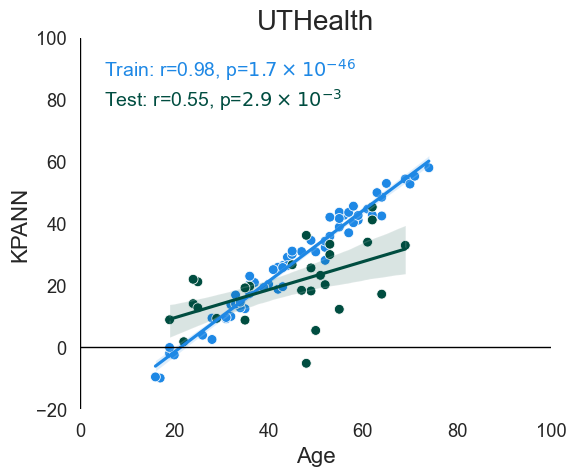

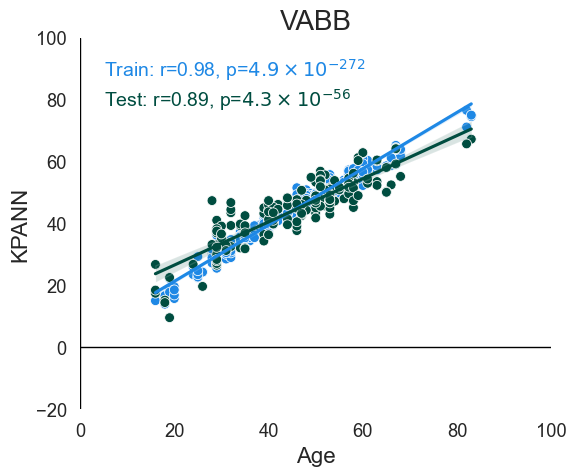

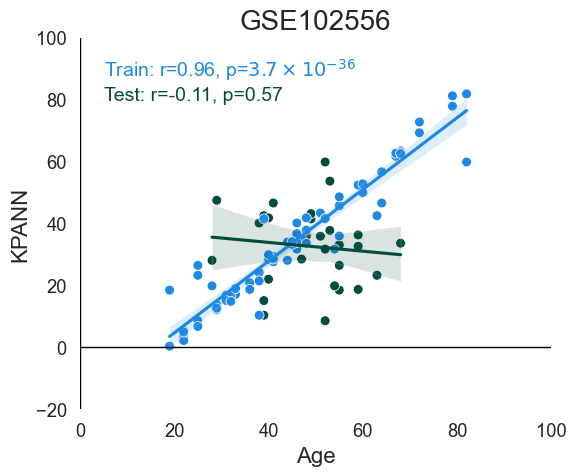

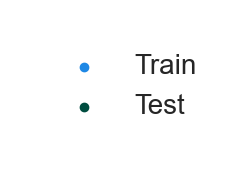

In [6]:
# -------------------------------------------------------------------
# Set parameters for Seaborn
# -------------------------------------------------------------------
sns.set(style="white", font_scale=1.2)

# Get cohorts and define consistent colors for Train/Test
cohorts = kpann2["Bank"].unique()
colors = {"Train": "#1E88E5", "Test": "#004D40"}

# -------------------------------------------------------------------
# 1. Loop over cohorts and make a scatter + regression plot
# -------------------------------------------------------------------
for idx, cohort in enumerate(cohorts):
    df_cohort = kpann2[kpann2["Bank"] == cohort]

    fig, ax = plt.subplots(figsize=(6, 5))

    # Scatter plot of observed vs predicted (by Type)
    sns.scatterplot(
        data=df_cohort,
        x="Age",
        y="KPANN_brain",
        hue="Type",
        #style="Type",
        palette=colors,
        ax=ax,
        s=50,
        legend=False  # Turn off legend (will add separately later)
    )

    # Fit regression line separately for Train and Test
    for i, t in enumerate(["Train", "Test"]):
        df_type = df_cohort[df_cohort["Type"] == t]
        
        # Add regression line
        sns.regplot(
            data=df_type,
            x="Age",
            y="KPANN_brain",
            scatter=False,
            ax=ax,
            color=colors[t],
            line_kws={"label": f"{t} fit"}  # label only for clarity
        )

        # Compute Pearson correlation and R²
        corr, pval = pearsonr(df_type["Age"], df_type["KPANN_brain"])
        r = corr
        #r2 = corr**2 # Uncomment if Variance explained is needed it

        # Dynamic formatting of p-values
        if pval >= 0.05:  
            # show as decimal with 2 digits if >= 0.001
            p_text = f"{pval:.2f}"
        else:
            # show in scientific notation if < 0.001
            mantissa, exponent = f"{pval:.1e}".split("e")
            p_text = rf"${mantissa} \times 10^{{{int(exponent)}}}$"

        # Annotate R² and p-value on plot
        ax.text(
            0.05, 0.95 - i*0.08,
            f"{t}: r={r:.2f}, p={p_text}",
            transform=ax.transAxes,
            color=colors[t],
            fontsize=14,
            verticalalignment='top'
        )

    # Clean up axes
    ax.grid(False)
    sns.despine(ax=ax, left=True, bottom=True)

    # Titles and labels
    ax.set_title(f"{cohort}", fontsize=20)
    ax.set_ylabel("KPANN", fontsize=16)
    ax.set_xlabel("Age", fontsize=16)

    # Add horizontal and vertical reference lines
    ax.axhline(0, color='black', linewidth=1, linestyle='-')
    ax.axvline(0, color='black', linewidth=1, linestyle='-')

    # Set Y-axis limits (force baseline to -20)
    #ax.set_ylim(-20, df_cohort["KPANN_brain"].max() + 5)
    ax.set_ylim(-20, 100)
    ax.set_xlim(0, 100)

    # Tight layout so labels don’t overlap
    plt.tight_layout()

    # Save each plot as high-resolution PDF (uncomment when ready)
    plt.savefig(f"00Fig2a_vs_Age_{cohort}.pdf", dpi=600, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 2. Make a standalone legend plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 2))  # adjust size of legend-only panel

# Create dummy scatter points to populate legend
scatter_train = ax.scatter([], [], color=colors["Train"], label="Train")
scatter_test = ax.scatter([], [], color=colors["Test"], label="Test")

# Hide the axes
ax.axis("off")

# Add the legend centered in the panel
leg = ax.legend(frameon=False, fontsize=20, loc="center")

# Save legend as a separate panel (uncomment when ready)
plt.savefig("00Fig2a_legend_panel.pdf", bbox_inches="tight", dpi=600)
plt.show()

In [ ]:
# --- 3. Compute RMSE and correlation per clock per dataset ---
results = []

age_col = 'AgeDeath'
clock_cols = [col for col in combined_df.columns if col.endswith('_brain')]

for source in combined_df['Source'].unique():
    sub_df = combined_df[combined_df['Source'] == source]
    if 'Age' not in sub_df.columns:
        raise ValueError(f"'Age' column not found in source {source}")
    y_true = sub_df['Age']
        
    for col in clock_cols:
        if col in sub_df.columns:
            y_pred = sub_df[col]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            corr = y_true.corr(y_pred)
            results.append({
                'Clock': col,
                'ClockType': col.replace('_brain', ''),
                'Tissue': 'brain',
                'RMSE': rmse,
                'Correlation': corr,
                'Source': source
            })

results_df = pd.DataFrame(results)
results_df["ClockType"] = results_df["ClockType"].str.replace(r"(?i)all", "All", regex=True)

# --- 4. Plot RMSE by Clock, separating KPANN and saving figure ---
# Separate KPANN from the rest
kpann_df = results_df[results_df['ClockType'].str.contains("KPANN", case=False)]
non_kpann_df = results_df[~results_df['ClockType'].str.contains("KPANN", case=False)]

# Sort clocks by mean RMSE (excluding KPANN)
mean_rmse_order = non_kpann_df.groupby('ClockType')['RMSE'].mean().sort_values().index

# Determine width ratio based on number of bars
width_ratio = [len(non_kpann_df['ClockType'].unique()), len(kpann_df['ClockType'].unique())]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': width_ratio})
sns.set(style="whitegrid")

# Left: all clocks except KPANN
sns.barplot(
    data=non_kpann_df,
    x='ClockType',
    y='RMSE',
    hue='Source',
    palette='Set2',
    order=mean_rmse_order,
    errorbar='se',
    ax=axes[0],
    width=0.7
)
axes[0].set_title("RMSE in all signatures of RNAAgeCalc", fontsize=20, pad=20)
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE (years)", fontsize=16)
axes[0].tick_params(axis='x', rotation=90, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].axhline(3.5, color='red', linestyle='--', linewidth=1.5)
axes[0].grid(False, axis='y')
axes[0].get_legend().remove()
axes[0].set_ylim(0, 50)

# Right: KPANN only
if not kpann_df.empty:
    sns.barplot(
        data=kpann_df,
        x='ClockType',
        y='RMSE',
        hue='Source',
        palette='Set2',
        order=["KPANN"],
        errorbar='se',
        ax=axes[1],
        width=0.7
    )
    axes[1].set_title("RMSE in Deep Clock (KPANN)", fontsize=20, pad=20)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    axes[1].tick_params(axis='x', rotation=90, labelsize=16)
    axes[1].tick_params(axis='y', labelsize=16)
    axes[1].axhline(3.5, color='red', linestyle='--', linewidth=1.5)
    axes[1].grid(False, axis='y')
    axes[1].get_legend().remove()
    axes[1].set_ylim(0, 50)

# Single legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Dataset",
    title_fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=16
)

plt.tight_layout()
plt.savefig("01Fig2a_by_Clock_Brain.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.show()

# Save dataframe
#results_df.to_csv("00Sup_RMSE_Correlation_by_Clock_Brain.csv", index=False)

In [8]:
# --- Get clock columns ---
clock_cols = [col for col in combined_df.columns if col.endswith("_brain")]

# --- Melt into long format ---
long_df = combined_df.melt(
    id_vars=["Source", "Age"],   # keep these columns
    value_vars=clock_cols,       # melt all clock predictions
    var_name="ClockType",
    value_name="PredictedAge"
)

# --- Clean up ClockType labels ---
long_df["ClockType"] = long_df["ClockType"].str.replace("_brain", "", regex=False)
long_df["ClockType"] = long_df["ClockType"].str.replace("all", "All", regex=False)

long_df.head()

,Source,Age,ClockType,PredictedAge
0,UTHealth,17,DESeq2,72.481142
1,UTHealth,31,DESeq2,81.060972
2,UTHealth,43,DESeq2,81.798013
3,UTHealth,44,DESeq2,68.112888
4,UTHealth,56,DESeq2,62.353245


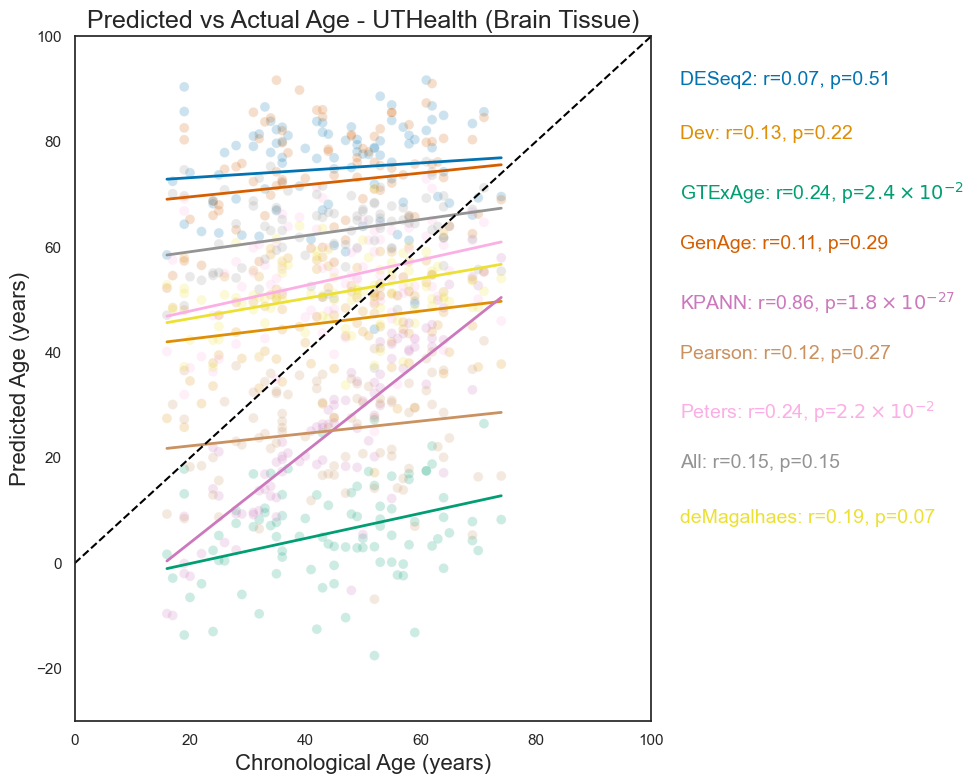

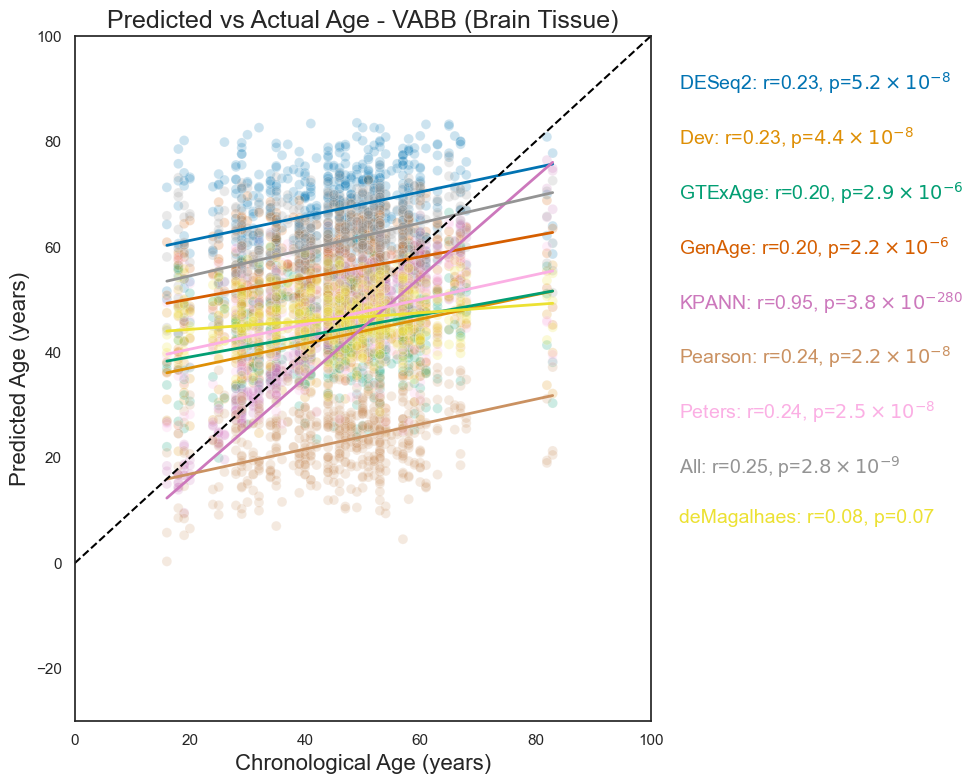

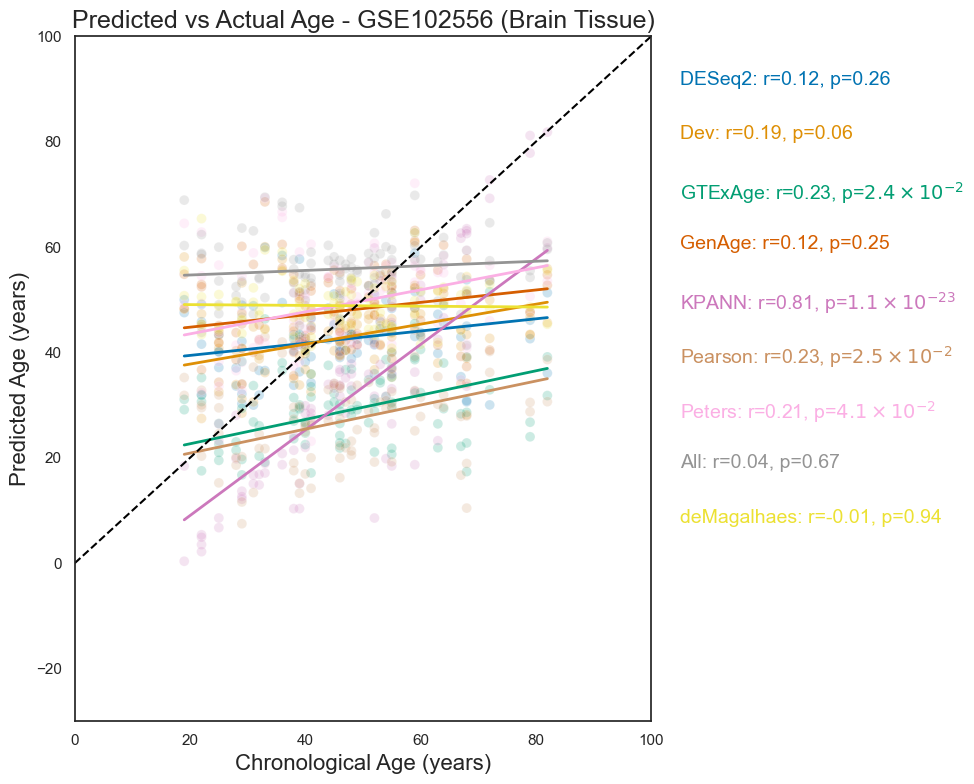

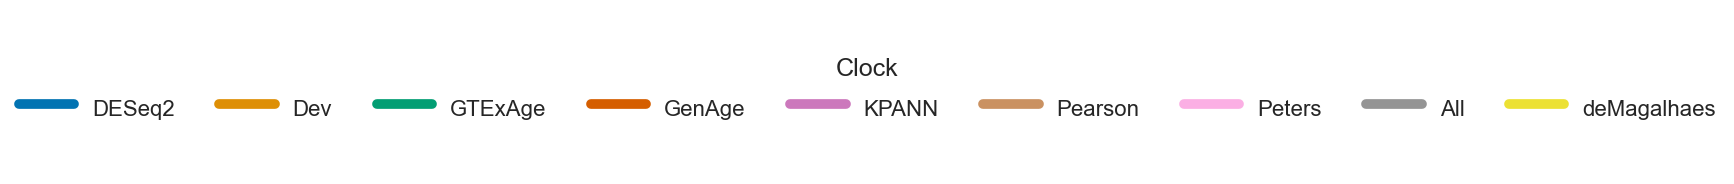

In [9]:
sns.set(style="white")

# Color-blind-friendly palette
clock_types = long_df["ClockType"].unique()
palette = sns.color_palette("colorblind", n_colors=len(clock_types))

# Loop over each cohort
for cohort in long_df["Source"].unique():
    cohort_df = long_df[long_df["Source"] == cohort]
    
    plt.figure(figsize=(10, 8))
    ax = sns.scatterplot(
        data=cohort_df,
        x="Age",
        y="PredictedAge",
        hue="ClockType",
        palette=palette,
        alpha=0.2,
        s=50,
        legend=False
    )
    
    # Add correlation lines (simple trend from min to max Age)
    for i, clock in enumerate(clock_types):
        clock_df = cohort_df[cohort_df["ClockType"] == clock]
        if clock_df.empty:
            continue
        
        # Pearson correlation
        r_value, p_value = stats.pearsonr(clock_df["Age"], clock_df["PredictedAge"])
        #r2 = r_value**2 # Uncomment if Variance is need it
        r = r_value

        
        # Draw trend line: line from min to max Age using correlation slope
        x_vals = np.array([clock_df["Age"].min(), clock_df["Age"].max()])
        y_vals = r_value * (x_vals - x_vals.mean()) + clock_df["PredictedAge"].mean()
        ax.plot(x_vals, y_vals, color=palette[i], lw=2)
        
        # Format p-value
        if p_value >= 0.05:
            p_text = f"{p_value:.2f}"
        else:
            mantissa, exponent = f"{p_value:.1e}".split("e")
            p_text = rf"${mantissa} \times 10^{{{int(exponent)}}}$"
        
        # Annotate R² and p-value
        ax.text(
            1.05, 0.95 - 0.08*i,
            f"{clock}: r={r:.2f}, p={p_text}",
            color=palette[i],
            fontsize=14,
            transform=ax.transAxes,
            verticalalignment='top'
        )
    
    # Add 1:1 reference line
    ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=1.5)
    
    ax.set_title(f"Predicted vs Actual Age - {cohort} (Brain Tissue)", fontsize=18)
    ax.set_xlabel("Chronological Age (years)", fontsize=16)
    ax.set_ylabel("Predicted Age (years)", fontsize=16)
    ax.set_xlim(0, 100)
    ax.set_ylim(-30, 100)
    
    plt.tight_layout()
    # Save each figure
    filename = f"00SupFigs1a_Age_vs_Predicted_{cohort}_Brain_corr.pdf"
    plt.savefig(filename, format="pdf", dpi=600, bbox_inches="tight")
    plt.show()

# Palette for clocks (color-blind friendly)
clock_types = long_df["ClockType"].unique()
palette = sns.color_palette("colorblind", n_colors=len(clock_types))

# Create dummy plot to generate handles
fig, ax = plt.subplots(figsize=(12, 2))  # wider for many clocks
for i, clock in enumerate(clock_types):
    ax.plot([], [], color=palette[i], label=clock, linewidth=7)  # empty plot for legend

# Create the legend
leg = ax.legend(
    title="Clock",
    loc="center",
    ncol=len(clock_types),  # all clocks in a row
    frameon=False,
    fontsize=16,
    title_fontsize=18,
    handlelength=2.5,  # longer lines
    handleheight=2
)

# Remove axes and background
ax.axis("off")
fig.tight_layout()

# Save the legend separately
plt.savefig("03Legend_Clocks_Brain.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
# --- Clean labels based on actual matrix ---
clean_labels = [
    c.replace("_brain", "").replace("all", "All") if c != "Age" else "Age"
    for c in r_matrix.columns
]
print(clean_labels)
print(r_matrix.columns)

['Age', 'DESeq2', 'Dev', 'GTExAge', 'GenAge', 'KPANN', 'Pearson', 'Peters', 'All', 'deMagalhaes']
Index(['Age', 'DESeq2_brain', 'Dev_brain', 'GTExAge_brain', 'GenAge_brain',
       'KPANN_brain', 'Pearson_brain', 'Peters_brain', 'all_brain',
       'deMagalhaes_brain'],
      dtype='object')


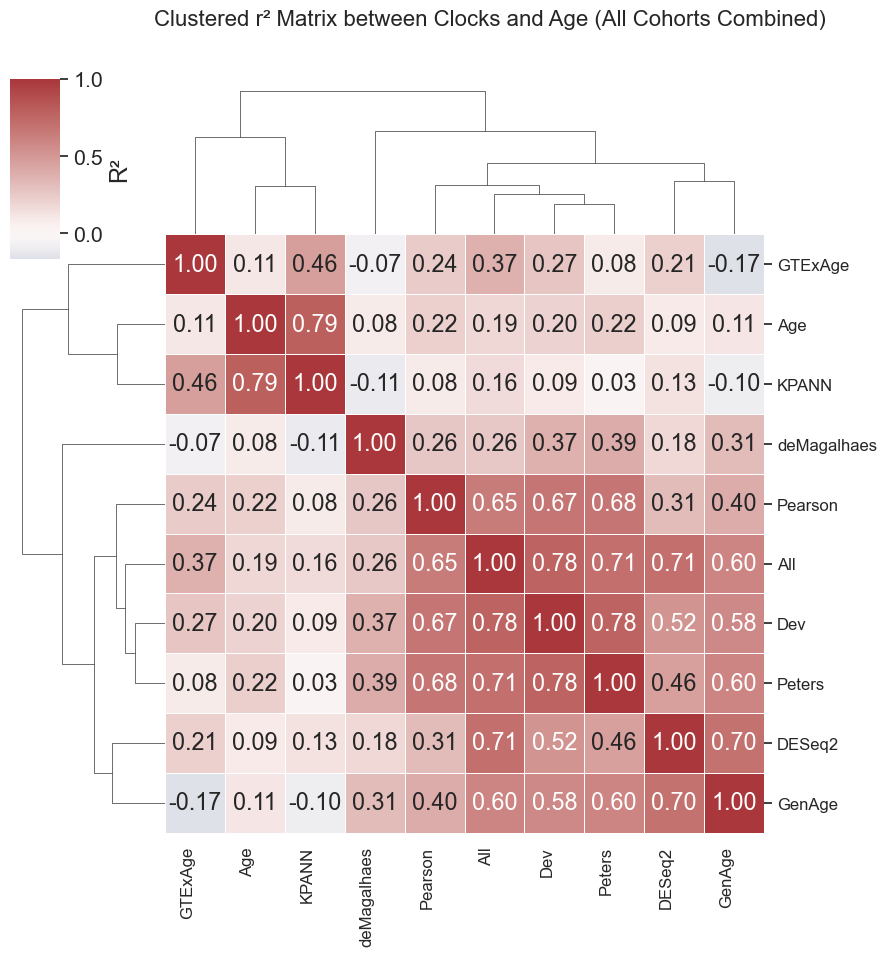

In [13]:
# --- Compute correlation and R² matrix from the whole combined_df ---
corr_matrix = combined_df[all_cols].corr(numeric_only=True)
r_matrix = corr_matrix

# --- Clustermap ---
sns.set(font_scale=1.4)
g = sns.clustermap(
    r_matrix,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "R²"},
    linewidths=0.5
)

# --- Fix tick labels according to the dendrogram order ---
g.ax_heatmap.set_xticklabels(
    [clean_labels[i] for i in g.dendrogram_col.reordered_ind],
    rotation=90, ha="right", fontsize=12
)
g.ax_heatmap.set_yticklabels(
    [clean_labels[i] for i in g.dendrogram_row.reordered_ind],
    rotation=0, fontsize=12
)

# --- Title ---
plt.suptitle(
    "Clustered r² Matrix between Clocks and Age (All Cohorts Combined)",
    fontsize=16, y=1.05
)

plt.savefig("00Fig2a_clustergram_allcohorts.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# Initialize list to collect results
corr_results = []

# Loop over each cohort
for cohort in long_df["Source"].unique():
    cohort_df = long_df[long_df["Source"] == cohort]
    
    for clock in clock_types:
        clock_df = cohort_df[cohort_df["ClockType"] == clock]
        if clock_df.empty:
            continue
        
        # Pearson correlation
        r_value, p_value = stats.pearsonr(clock_df["Age"], clock_df["PredictedAge"])
        r2 = r_value**2
        
        # Store results
        corr_results.append({
            "Cohort": cohort,
            "Clock": clock,
            "r": r_value,
            "R2": r2,
            "p_value": p_value,
            "n_samples": len(clock_df)
        })

# Convert results to DataFrame
corr_df = pd.DataFrame(corr_results)

# Save to CSV
#corr_df.to_csv("01SuppTable_Correlation_Age_vs_Predicted_Clocks.csv", index=False)

In [4]:
# Read both files
ret = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_gse102556-08172025.csv'
enRet = pd.read_csv(ret, index_col=0)
ret2 = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_uthealth-08182025.csv'
enRet2 = pd.read_csv(ret2, index_col=0)

# Add source column to each
enRet["Source"] = "GSE102556"
enRet2["Source"] = "UTHealth"

# Concatenate along rows (so Source column is preserved)
combined_df2 = pd.concat([enRet, enRet2], axis=0, ignore_index=False)

# Reset index if you want a clean continuous index
combined_df2.reset_index(inplace=True)
combined_df2.rename(columns={"index": "SampleID"}, inplace=True)
combined_df2

,SampleID,Actual_Age,Predicted_ElasticNet,Predicted_DeepLearning,Predicted_ElasticNet_Stochastic,Predicted_DeepLearning_Stochastic,Source
0,S14.BA11,47,47.286596,46.053800,21.956768,22.953129,GSE102556
1,S17.BA11,41,40.909524,22.240500,26.519688,25.946888,GSE102556
2,S20.BA11,31,32.850170,27.220861,14.666239,16.698282,GSE102556
3,S23.BA11,19,23.948171,23.157152,19.274508,21.772709,GSE102556
4,S28.BA11,46,45.836763,37.918415,25.872570,24.990147,GSE102556
...,...,...,...,...,...,...,...
180,A67995,63,50.348354,41.703583,30.864792,31.065182,UTHealth
181,A67996,36,49.019974,29.035337,23.333821,21.391320,UTHealth
182,A67997,61,48.260497,27.981165,23.822408,22.541843,UTHealth
183,A67998,28,35.980747,36.136463,17.568902,17.257830,UTHealth


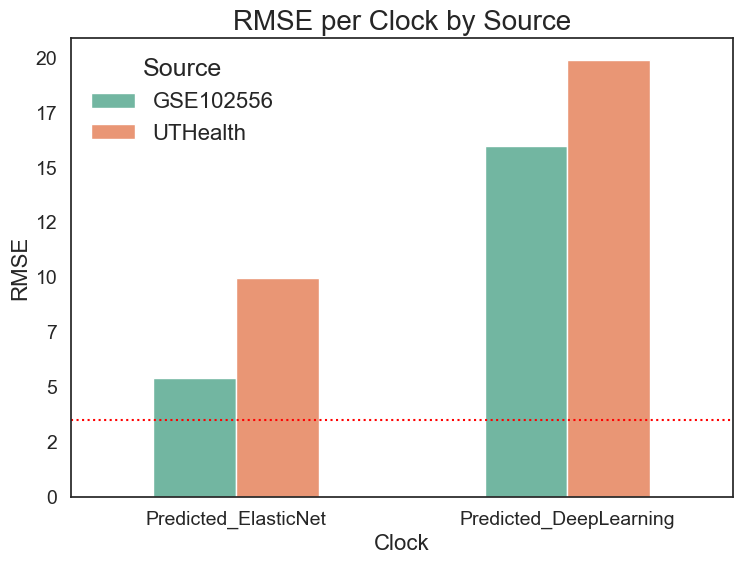

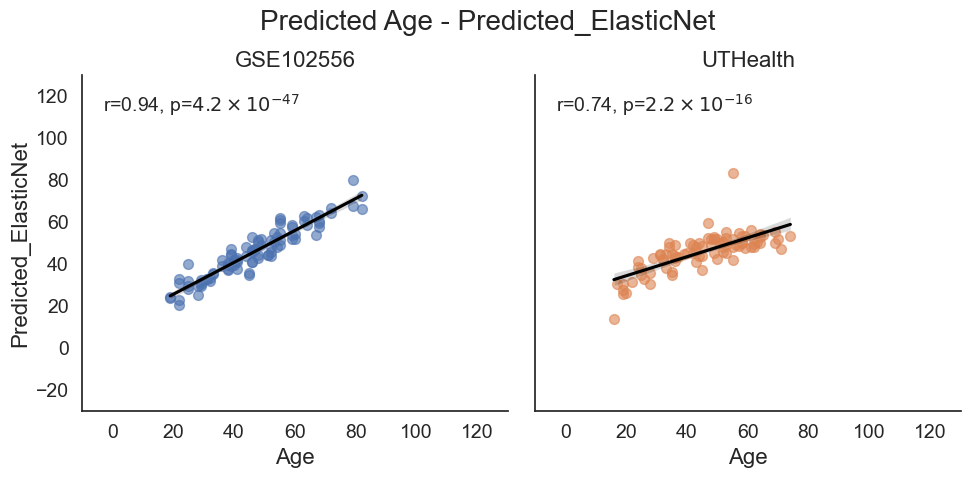

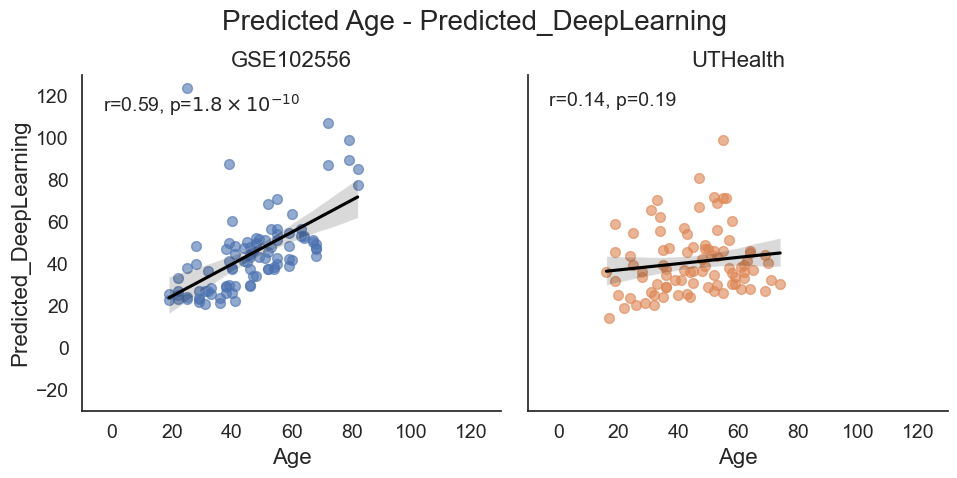

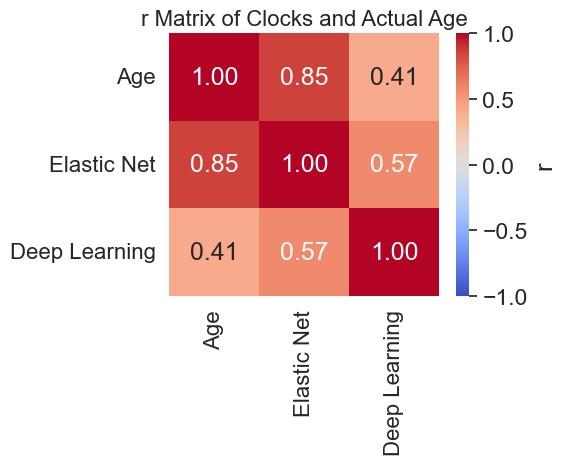

In [8]:
# --- 1. Compute RMSE and correlation per clock per dataset ---
results2 = []
clock_cols = ['Predicted_ElasticNet', 'Predicted_DeepLearning']

for source in combined_df2['Source'].unique():
    sub_df = combined_df2[combined_df2['Source'] == source]
    y_true = sub_df['Actual_Age']
    
    for col in clock_cols:
        if col in sub_df.columns:
            y_pred = sub_df[col]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            corr = y_true.corr(y_pred)
            results2.append({
                'Clock': col,
                'Tissue': 'brain',
                'RMSE': rmse,
                'Correlation': corr,
                'Source': source
            })

results_df2 = pd.DataFrame(results2)

# --- 1. Barplot: RMSE ---
plt.figure(figsize=(8,6))
sns.barplot(data=results_df2, x="Clock", y="RMSE", hue="Source", palette="Set2", width=0.5)
plt.title("RMSE per Clock by Source", fontsize=20)
plt.ylabel("RMSE", fontsize=16)
plt.xlabel("Clock", fontsize=16)
plt.axhline(3.5, color='red', linestyle='dotted', linewidth=1.5)
plt.legend(title="Source", frameon=False, fontsize=16)
plt.tight_layout()
# Increase font size of x and y ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Remove decimals from y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
plt.savefig("00Fig3_MSE_per_Clock_by_Source.pdf", dpi=600, format="pdf")
plt.show()

# --- 2. Scatterplot: Correlation (Actual vs Predicted Age per Source) ---
sns.set(style="white", font_scale=1.5)  # larger fonts
clock_cols = ['Predicted_ElasticNet', 'Predicted_DeepLearning']
for clock in clock_cols:
    g = sns.lmplot(
        data=combined_df2,
        x="Actual_Age",
        y=clock,
        col="Source",
        hue="Source",
        height=5,
        aspect=1,
        scatter_kws={'alpha':0.6, 's':50},  # slightly bigger points
        line_kws={'color':'black'}
    )    
    # Axis labels and titles
    g.set_axis_labels("Age", f"{clock}", fontsize=16)
    g.set_titles("{col_name}", size=16)
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle(f"Predicted Age - {clock}", fontsize=20)   
    # Increase tick label sizes
    for ax in g.axes.flat:
        ax.tick_params(labelsize=14)
        ax.set_xlim(-10, 130)
        ax.set_ylim(-30, 130)
        # Compute Pearson correlation
        x = combined_df2.loc[combined_df2["Source"] == ax.get_title(), "Actual_Age"]
        y = combined_df2.loc[combined_df2["Source"] == ax.get_title(), clock]
        r, p = pearsonr(x, y)
        #r2 = r**2
        r2 = r
        
        # Format p-value
        if p >= 0.001:
            p_text = f"{p:.2f}"
        else:
            mantissa, exponent = f"{p:.1e}".split("e")
            p_text = rf"${mantissa} \times 10^{{{int(exponent)}}}$"
        
        # Add annotation inside plot
        ax.text(
            0.05, 0.95,
            f"r={r:.2f}, p={p_text}",
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top'
        )    
    # Save figure
    g.savefig(f"00Fig3_Scatter_Age_vs_{clock}_with_R2.pdf", dpi=600, format="pdf")
    plt.show()

# --- 3. Matrix heatmap of R² (add Actual Age row/column) ---
# Build full correlation matrix including Actual_Age
cols_for_corr = ['Actual_Age'] + clock_cols
corr_matrix = combined_df2[cols_for_corr].corr()

# Example: rename columns/rows
new_labels = {
    'Actual_Age': 'Age',
    'Predicted_ElasticNet': 'Elastic Net',
    'Predicted_DeepLearning': 'Deep Learning'
    # add all clocks here as needed
}

# Rename the correlation matrix
corr_matrix_renamed = corr_matrix.rename(index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix_renamed, 
    annot=True, fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1,
    cbar_kws={"label": "r"}
)

# Increase tick label fonts
plt.xticks(fontsize=16, rotation=90)
plt.yticks(fontsize=16, rotation=0)
plt.title("r Matrix of Clocks and Actual Age", fontsize=16)
plt.tight_layout()
plt.savefig("00Fig3_R2_Matrix_Clocks_with_Age_retrained.pdf", dpi=600, format="pdf")
plt.show()